In [2]:
#!/usr/bin/env python3
"""
Dataset Loading and Examination Snippets
"""

import os
import sys
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Tuple
import torch

# Add project root to path (notebook-friendly version)
# Get the current working directory and go up to project root
current_dir = Path.cwd()
if current_dir.name == 'scripts':
    project_root = current_dir.parent
else:
    project_root = current_dir

sys.path.insert(0, str(project_root))
print(f"🔧 Project root set to: {project_root}")

# Import your utilities
from utils.data_utils import DataPathManager, PviDataset

def get_available_subjects(data_root: str) -> List[str]:
    """Get list of available subjects from data directory"""
    data_path = Path(data_root)
    subjects = []
    
    print(f"🔍 Scanning for subjects in: {data_path}")
    for file_path in data_path.glob("subject*_baseline_masked.h5"):
        subject = file_path.stem.split('_')[0]
        subjects.append(subject)
        print(f"   Found: {file_path.name}")
    
    return sorted(subjects)

# Setup data root
data_root = os.getenv('BP_DATA_ROOT', '/home/lucas_takanori/phd/data')
print(f"📁 Data root: {data_root}")

# Get available subjects
subjects = get_available_subjects(data_root)
print(f"\n✅ Found {len(subjects)} subjects: {subjects}")

🔧 Project root set to: /home/lucas_takanori/phd/bp_prediction
📁 Data root: /home/lucas_takanori/phd/data
🔍 Scanning for subjects in: /home/lucas_takanori/phd/data
   Found: subject001_baseline_masked.h5
   Found: subject036_baseline_masked.h5
   Found: subject033_baseline_masked.h5
   Found: subject030_baseline_masked.h5
   Found: subject005_baseline_masked.h5
   Found: subject034_baseline_masked.h5
   Found: subject032_baseline_masked.h5
   Found: subject025_baseline_masked.h5
   Found: subject010_baseline_masked.h5
   Found: subject018_baseline_masked.h5
   Found: subject006_baseline_masked.h5
   Found: subject003_baseline_masked.h5
   Found: subject029_baseline_masked.h5
   Found: subject007_baseline_masked.h5
   Found: subject019_baseline_masked.h5
   Found: subject037_baseline_masked.h5
   Found: subject004_baseline_masked.h5
   Found: subject021_baseline_masked.h5
   Found: subject028_baseline_masked.h5
   Found: subject024_baseline_masked.h5
   Found: subject016_baseline_masked.

In [11]:
def examine_h5_file_structure(file_path: Path) -> Dict:
    """Examine the raw HDF5 file structure"""
    print(f"\n📁 Examining HDF5 structure: {file_path.name}")
    
    structure = {}
    
    def visit_func(name, obj):
        if isinstance(obj, h5py.Group):
            structure[name] = {"type": "Group", "keys": list(obj.keys())}
        elif isinstance(obj, h5py.Dataset):
            structure[name] = {
                "type": "Dataset", 
                "shape": obj.shape, 
                "dtype": obj.dtype,
                "size": obj.size
            }
    
    try:
        with h5py.File(file_path, 'r') as h5f:
            h5f.visititems(visit_func)
            
            # Get top-level groups
            top_level = list(h5f.keys())
            print(f"   Top-level groups: {top_level}")
            
            # Print detailed structure
            for name, info in structure.items():
                if info["type"] == "Group":
                    print(f"   📁 {name}: {info['keys']}")
                else:
                    print(f"   📄 {name}: shape={info['shape']}, dtype={info['dtype']}")
            
    except Exception as e:
        print(f"   ❌ Error reading file: {e}")
        return {}
    
    return structure

# Example usage for first subject
if subjects:
    first_subject = subjects[10]
    print(f"\n🔍 Examining first subject: {first_subject}")
    data_manager = DataPathManager(
        subject=first_subject,
        session="baseline",
        root=data_root
    )
    
    if data_manager._h5_path.exists():
        print(f"📁 Found file: {data_manager._h5_path}")
        h5_structure = examine_h5_file_structure(data_manager._h5_path)
    else:
        print(f"❌ File not found: {data_manager._h5_path}")
else:
    print("❌ No subjects available to examine")
    
if subjects:
    first_subject = subjects[0]
    print(f"\n🔍 Examining first subject: {first_subject}")
    data_manager = DataPathManager(
        subject=first_subject,
        session="baseline",
        root=data_root
    )
    
    if data_manager._h5_path.exists():
        print(f"📁 Found file: {data_manager._h5_path}")
        h5_structure = examine_h5_file_structure(data_manager._h5_path)
    else:
        print(f"❌ File not found: {data_manager._h5_path}")
else:
    print("❌ No subjects available to examine")


🔍 Examining first subject: subject014
Looking for data file at: /home/lucas_takanori/phd/data/subject014_baseline_masked.h5
DataPathManager successfully initiated!
📁 Found file: /home/lucas_takanori/phd/data/subject014_baseline_masked.h5

📁 Examining HDF5 structure: subject014_baseline_masked.h5
   Top-level groups: ['data', 'masks', 'metadata', 'stats']
   📁 data: ['bp', 'ecg', 'pviHP', 'pviLP']
   📁 data/bp: ['signal']
   📄 data/bp/signal: shape=(50, 1801), dtype=float64
   📁 data/ecg: ['signal']
   📄 data/ecg/signal: shape=(50, 1801), dtype=float64
   📁 data/pviHP: ['img', 'reactance', 'resistance', 'signal']
   📄 data/pviHP/img: shape=(50, 32, 32, 1801), dtype=float64
   📄 data/pviHP/reactance: shape=(50, 32, 1801), dtype=float64
   📄 data/pviHP/resistance: shape=(50, 32, 1801), dtype=float64
   📄 data/pviHP/signal: shape=(50, 1801), dtype=float64
   📁 data/pviLP: ['img', 'reactance', 'resistance', 'signal']
   📄 data/pviLP/img: shape=(50, 32, 32, 1801), dtype=float64
   📄 data/pv

In [17]:
def examine_dataset_masks(dataset: PviDataset) -> Dict:
    """Examine the masks in the dataset"""
    print(f"\n🎭 Examining masks for dataset: {dataset.file_name}")
    
    mask_info = {
        "has_masks": False,
        "num_masks": 0,
        "mask_ranges": [],
        "mask_details": {}
    }
    
    # Check metadata for masks
    if hasattr(dataset, '_h5meta') and 'mask' in dataset._h5meta:
        masks = dataset._h5meta['mask']
        if masks is not None:
            mask_info["has_masks"] = True
            mask_info["num_masks"] = len(masks)
            mask_info["mask_ranges"] = masks
            
            print(f"   ✅ Masks found: {len(masks)} total")
            print(f"   📊 Mask ranges:")
            for i, mask_range in enumerate(masks[:10]):  # Show first 10
                print(f"      {i}: {mask_range}")
            if len(masks) > 10:
                print(f"      ... and {len(masks) - 10} more")
                
            # Analyze mask statistics
            mask_lengths = [end - start for start, end in masks]
            mask_info["mask_details"] = {
                "min_length": min(mask_lengths),
                "max_length": max(mask_lengths),
                "mean_length": np.mean(mask_lengths),
                "std_length": np.std(mask_lengths)
            }
            
            print(f"   📈 Mask length statistics:")
            print(f"      Min: {mask_info['mask_details']['min_length']}")
            print(f"      Max: {mask_info['mask_details']['max_length']}")
            print(f"      Mean: {mask_info['mask_details']['mean_length']:.2f}")
            print(f"      Std: {mask_info['mask_details']['std_length']:.2f}")
        else:
            print(f"   ⚠️  Mask key exists but is None")
    else:
        print(f"   ❌ No masks found in metadata")
    
    return mask_info

# Example usage
if subjects:
    first_subject = subjects[10]
    print(f"\n🎭 Loading dataset for mask examination: {first_subject}")
    data_manager = DataPathManager(
        subject=first_subject,
        session="baseline", 
        root=data_root
    )
    
    if data_manager._h5_path.exists():
        print("📊 Loading PviDataset...")
        dataset = PviDataset(str(data_manager._h5_path))
        mask_info = examine_dataset_masks(dataset)
    else:
        print(f"❌ File not found: {data_manager._h5_path}")
else:
    print("❌ No subjects available for mask examination")


🎭 Loading dataset for mask examination: subject014
Looking for data file at: /home/lucas_takanori/phd/data/subject014_baseline_masked.h5
DataPathManager successfully initiated!
📊 Loading PviDataset...
Using Torch version: 2.6.0+cu124
Data directory set to:
	/home/lucas_takanori/phd/data
Found HDF5 data: 'subject014_baseline_masked.h5'
Loading metadata...
⚠️  'mask' not found in metadata. Will attempt to generate one.
	 ...Done!
PviDataset successfully initiated!
Loading raw data...
	 ...Done! (15.38 seconds)
Number of periods: 1801
Generating default mask from 1801 periods.
Stacking samples (1801 total):
	 ...100/1801 samples
	 ...200/1801 samples
	 ...300/1801 samples
	 ...400/1801 samples
	 ...500/1801 samples
	 ...600/1801 samples
	 ...700/1801 samples
	 ...800/1801 samples
	 ...900/1801 samples
	 ...1000/1801 samples
	 ...1100/1801 samples
	 ...1200/1801 samples
	 ...1300/1801 samples
	 ...1400/1801 samples
	 ...1500/1801 samples
	 ...1600/1801 samples
	 ...1700/1801 samples
	 ...

In [5]:
def examine_sample_structure(dataset: PviDataset, sample_idx: int = 0) -> Dict:
    """Examine the structure of a single sample"""
    print(f"\n🔬 Examining sample structure (sample {sample_idx}):")
    
    if len(dataset) == 0:
        print("   ❌ Dataset is empty")
        return {}
    
    sample = dataset[sample_idx]
    sample_info = {}
    
    print(f"   📊 Sample keys: {list(sample.keys())}")
    
    for key in sample.keys():
        print(f"\n   🔑 Key: '{key}'")
        if isinstance(sample[key], dict):
            sample_info[key] = {}
            for subkey in sample[key].keys():
                data = sample[key][subkey]
                if isinstance(data, torch.Tensor):
                    shape = tuple(data.shape)
                    dtype = data.dtype
                    sample_info[key][subkey] = {
                        "shape": shape,
                        "dtype": str(dtype),
                        "min": float(data.min()),
                        "max": float(data.max()),
                        "mean": float(data.mean()),
                        "std": float(data.std())
                    }
                    print(f"      {subkey}: shape={shape}, dtype={dtype}")
                    print(f"                 range=[{data.min():.4f}, {data.max():.4f}]")
                    print(f"                 mean={data.mean():.4f}, std={data.std():.4f}")
                else:
                    sample_info[key][subkey] = {"type": str(type(data))}
                    print(f"      {subkey}: {type(data)}")
        else:
            if isinstance(sample[key], torch.Tensor):
                shape = tuple(sample[key].shape)
                dtype = sample[key].dtype
                sample_info[key] = {
                    "shape": shape,
                    "dtype": str(dtype),
                    "min": float(sample[key].min()),
                    "max": float(sample[key].max()),
                    "mean": float(sample[key].mean()),
                    "std": float(sample[key].std())
                }
                print(f"   Direct tensor: shape={shape}, dtype={dtype}")
                print(f"                  range=[{sample[key].min():.4f}, {sample[key].max():.4f}]")
            else:
                sample_info[key] = {"type": str(type(sample[key]))}
                print(f"   Direct data: {type(sample[key])}")
    
    return sample_info

# Example usage
if subjects:
    first_subject = subjects[0]
    print(f"\n🔬 Loading dataset for sample structure examination: {first_subject}")
    data_manager = DataPathManager(
        subject=first_subject,
        session="baseline",
        root=data_root
    )
    
    if data_manager._h5_path.exists():
        print("📊 Loading PviDataset...")
        dataset = PviDataset(str(data_manager._h5_path))
        sample_info = examine_sample_structure(dataset)
    else:
        print(f"❌ File not found: {data_manager._h5_path}")
else:
    print("❌ No subjects available for sample examination")


🔬 Loading dataset for sample structure examination: subject001
Looking for data file at: /home/lucas_takanori/phd/data/subject001_baseline_masked.h5
DataPathManager successfully initiated!
📊 Loading PviDataset...
Using Torch version: 2.6.0+cu124
Data directory set to:
	/home/lucas_takanori/phd/data
Found HDF5 data: 'subject001_baseline_masked.h5'
Loading metadata...
	 ...Done!
PviDataset successfully initiated!
Loading raw data...
	 ...Done! (1.48 seconds)
Number of periods: 867
Stacking samples (400 total):
	 ...100/400 samples
	 ...200/400 samples
	 ...300/400 samples
	 ...400/400 samples
	 ...Done! (4.09 seconds)
Number of samples: 400
Finish loading PviDataset!

🔬 Examining sample structure (sample 0):
   📊 Sample keys: ['ecg', 'bp', 'pviLP', 'pviHP', 'stats']

   🔑 Key: 'ecg'
      signal: shape=(50,), dtype=torch.float32
                 range=[-0.1937, 0.4286]
                 mean=0.0298, std=0.1211

   🔑 Key: 'bp'
      signal: shape=(50,), dtype=torch.float32
               


🎨 Visualizing masks for: subject014
Looking for data file at: /home/lucas_takanori/phd/data/subject014_baseline_masked.h5
DataPathManager successfully initiated!
Using Torch version: 2.6.0+cu124
Data directory set to:
	/home/lucas_takanori/phd/data
Found HDF5 data: 'subject014_baseline_masked.h5'
Loading metadata...
⚠️  'mask' not found in metadata. Will attempt to generate one.
	 ...Done!
PviDataset successfully initiated!
Loading raw data...
	 ...Done! (30.08 seconds)
Number of periods: 1801
Generating default mask from 1801 periods.
Stacking samples (1801 total):
	 ...100/1801 samples
	 ...200/1801 samples
	 ...300/1801 samples
	 ...400/1801 samples
	 ...500/1801 samples
	 ...600/1801 samples
	 ...700/1801 samples
	 ...800/1801 samples
	 ...900/1801 samples
	 ...1000/1801 samples
	 ...1100/1801 samples
	 ...1200/1801 samples
	 ...1300/1801 samples
	 ...1400/1801 samples
	 ...1500/1801 samples
	 ...1600/1801 samples
	 ...1700/1801 samples
	 ...1800/1801 samples
	 ...1801/1801 sample

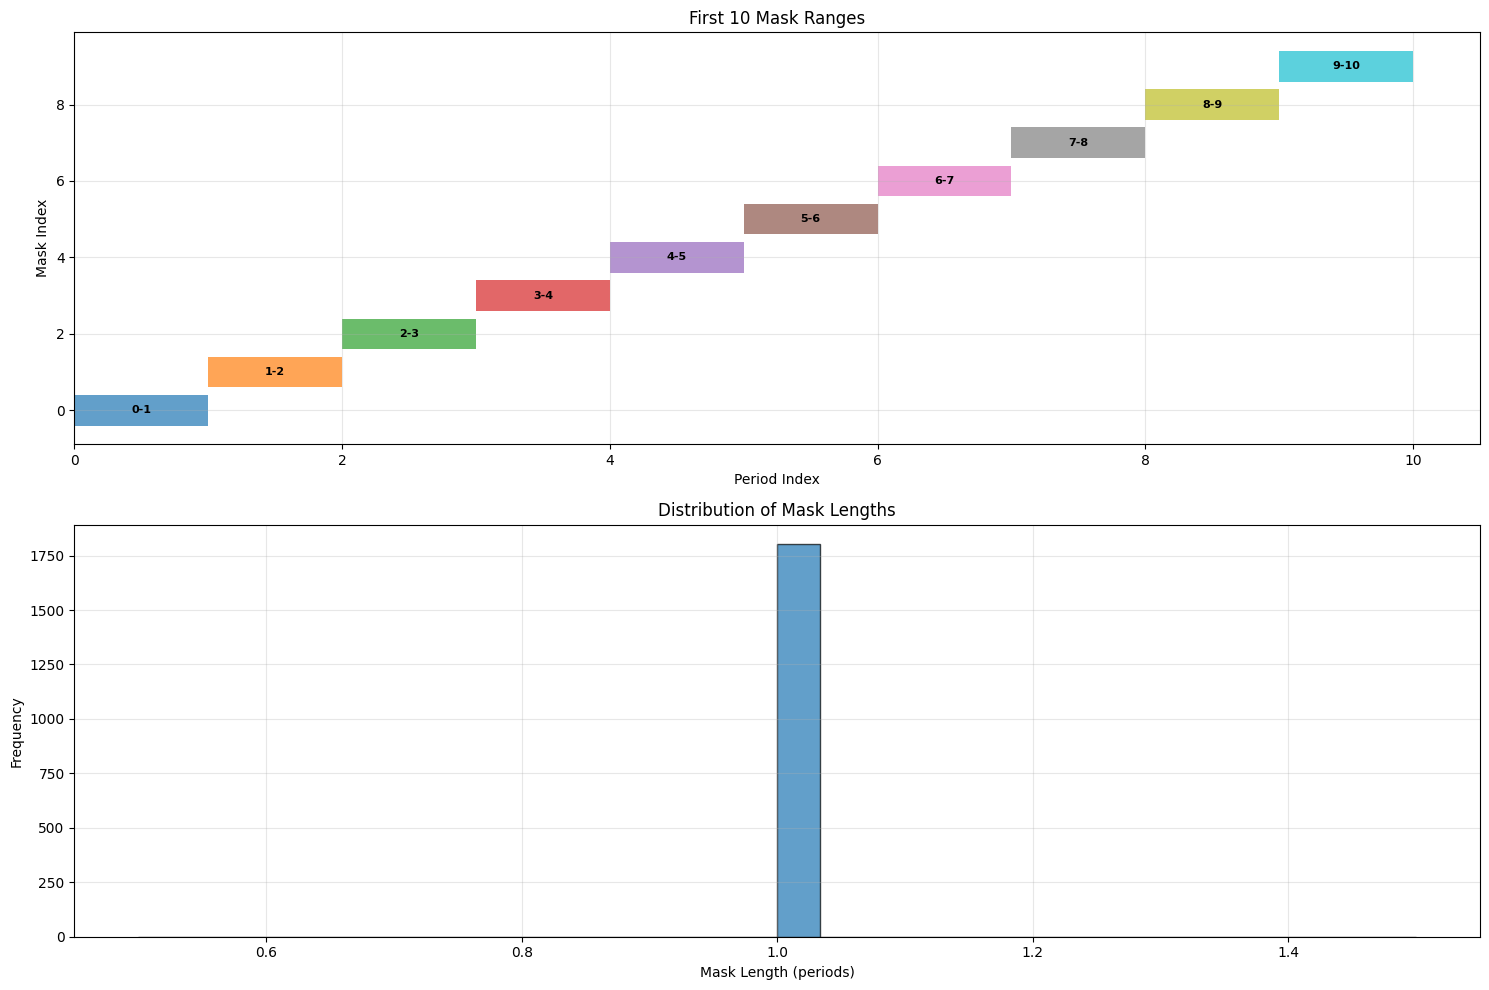

   ✅ Mask visualization saved as 'mask_analysis.png'


In [14]:
def visualize_masks(dataset: PviDataset, max_masks: int = 10):
    """Visualize the first few masks if available"""
    print(f"\n🎨 Visualizing masks (first {max_masks}):")
    
    if not hasattr(dataset, '_h5meta') or 'mask' not in dataset._h5meta or dataset._h5meta['mask'] is None:
        print("   ⚠️  No masks available for visualization")
        return
    
    masks = dataset._h5meta['mask']
    num_to_plot = min(len(masks), max_masks)
    
    if num_to_plot == 0:
        print("   ⚠️  No masks to visualize")
        return
    
    try:
        # Create a figure showing mask ranges
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
        
        # Plot 1: Mask ranges as horizontal bars
        for i, (start, end) in enumerate(masks[:num_to_plot]):
            ax1.barh(i, end - start, left=start, height=0.8, alpha=0.7)
            ax1.text(start + (end - start) / 2, i, f'{start}-{end}', 
                   ha='center', va='center', fontweight='bold', fontsize=8)
        
        ax1.set_xlabel('Period Index')
        ax1.set_ylabel('Mask Index')
        ax1.set_title(f'First {num_to_plot} Mask Ranges')
        ax1.grid(True, alpha=0.3)
        
        # Plot 2: Mask length distribution
        mask_lengths = [end - start for start, end in masks]
        ax2.hist(mask_lengths, bins=30, alpha=0.7, edgecolor='black')
        ax2.set_xlabel('Mask Length (periods)')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Distribution of Mask Lengths')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('mask_analysis.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"   ✅ Mask visualization saved as 'mask_analysis.png'")
        
    except Exception as e:
        print(f"   ❌ Error creating visualization: {e}")

# Example usage - visualize masks from first subject
if subjects:
    first_subject = subjects[10]
    print(f"\n🎨 Visualizing masks for: {first_subject}")
    data_manager = DataPathManager(
        subject=first_subject,
        session="baseline",
        root=data_root
    )
    
    if data_manager._h5_path.exists():
        dataset = PviDataset(str(data_manager._h5_path))
        visualize_masks(dataset)
    else:
        print(f"❌ File not found: {data_manager._h5_path}")
else:
    print("❌ No subjects available for mask visualization")


📊 Visualizing sample data for: subject014
Looking for data file at: /home/lucas_takanori/phd/data/subject014_baseline_masked.h5
DataPathManager successfully initiated!
Using Torch version: 2.6.0+cu124
Data directory set to:
	/home/lucas_takanori/phd/data
Found HDF5 data: 'subject014_baseline_masked.h5'
Loading metadata...
⚠️  'mask' not found in metadata. Will attempt to generate one.
	 ...Done!
PviDataset successfully initiated!
Loading raw data...
	 ...Done! (13.62 seconds)
Number of periods: 1801
Generating default mask from 1801 periods.
Stacking samples (1801 total):
	 ...100/1801 samples
	 ...200/1801 samples
	 ...300/1801 samples
	 ...400/1801 samples
	 ...500/1801 samples
	 ...600/1801 samples
	 ...700/1801 samples
	 ...800/1801 samples
	 ...900/1801 samples
	 ...1000/1801 samples
	 ...1100/1801 samples
	 ...1200/1801 samples
	 ...1300/1801 samples
	 ...1400/1801 samples
	 ...1500/1801 samples
	 ...1600/1801 samples
	 ...1700/1801 samples
	 ...1800/1801 samples
	 ...1801/1801 

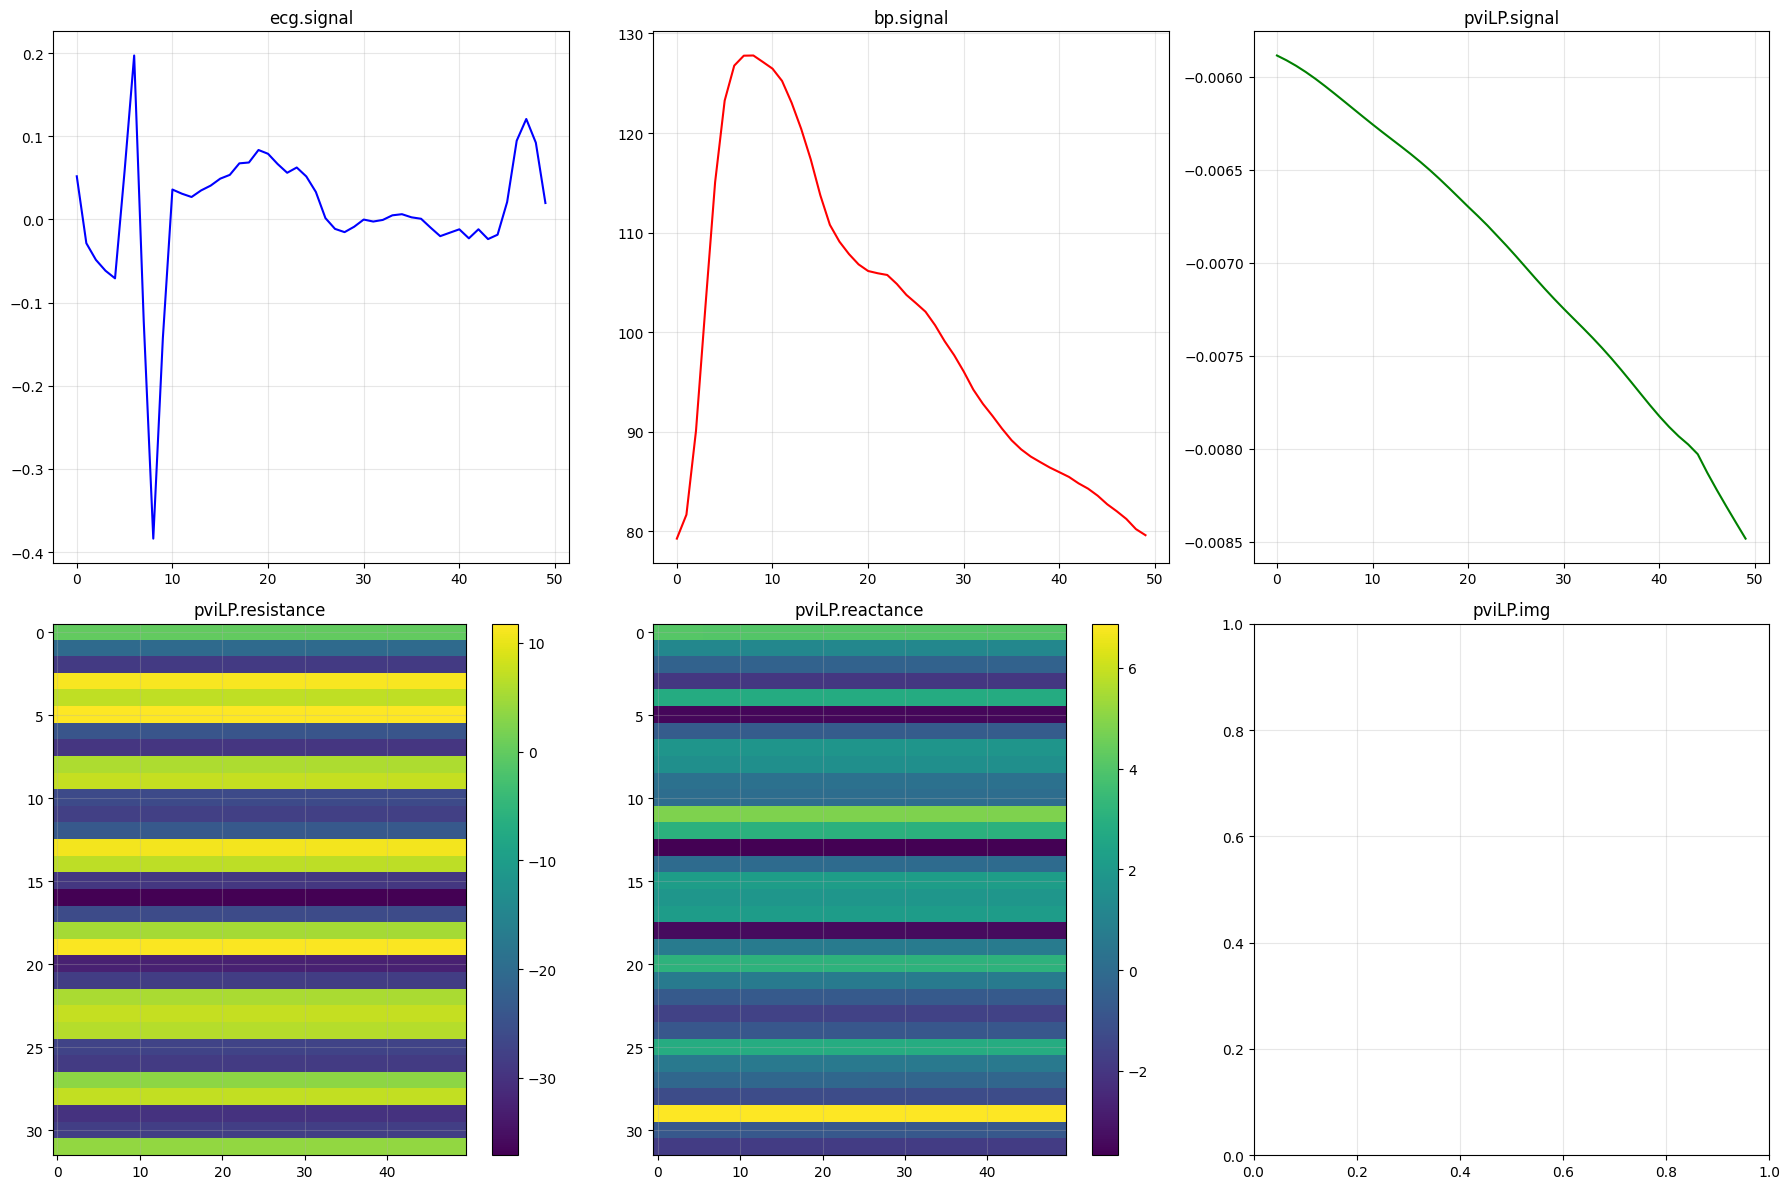

   ✅ Sample data visualization saved as 'sample_data_visualization.png'

📊 Visualizing sample data for: subject001
Looking for data file at: /home/lucas_takanori/phd/data/subject001_baseline_masked.h5
DataPathManager successfully initiated!
Using Torch version: 2.6.0+cu124
Data directory set to:
	/home/lucas_takanori/phd/data
Found HDF5 data: 'subject001_baseline_masked.h5'
Loading metadata...
	 ...Done!
PviDataset successfully initiated!
Loading raw data...
	 ...Done! (11.23 seconds)
Number of periods: 867
Stacking samples (400 total):
	 ...100/400 samples
	 ...200/400 samples
	 ...300/400 samples
	 ...400/400 samples
	 ...Done! (18.23 seconds)
Number of samples: 400
Finish loading PviDataset!

📊 Visualizing sample data (sample 0):


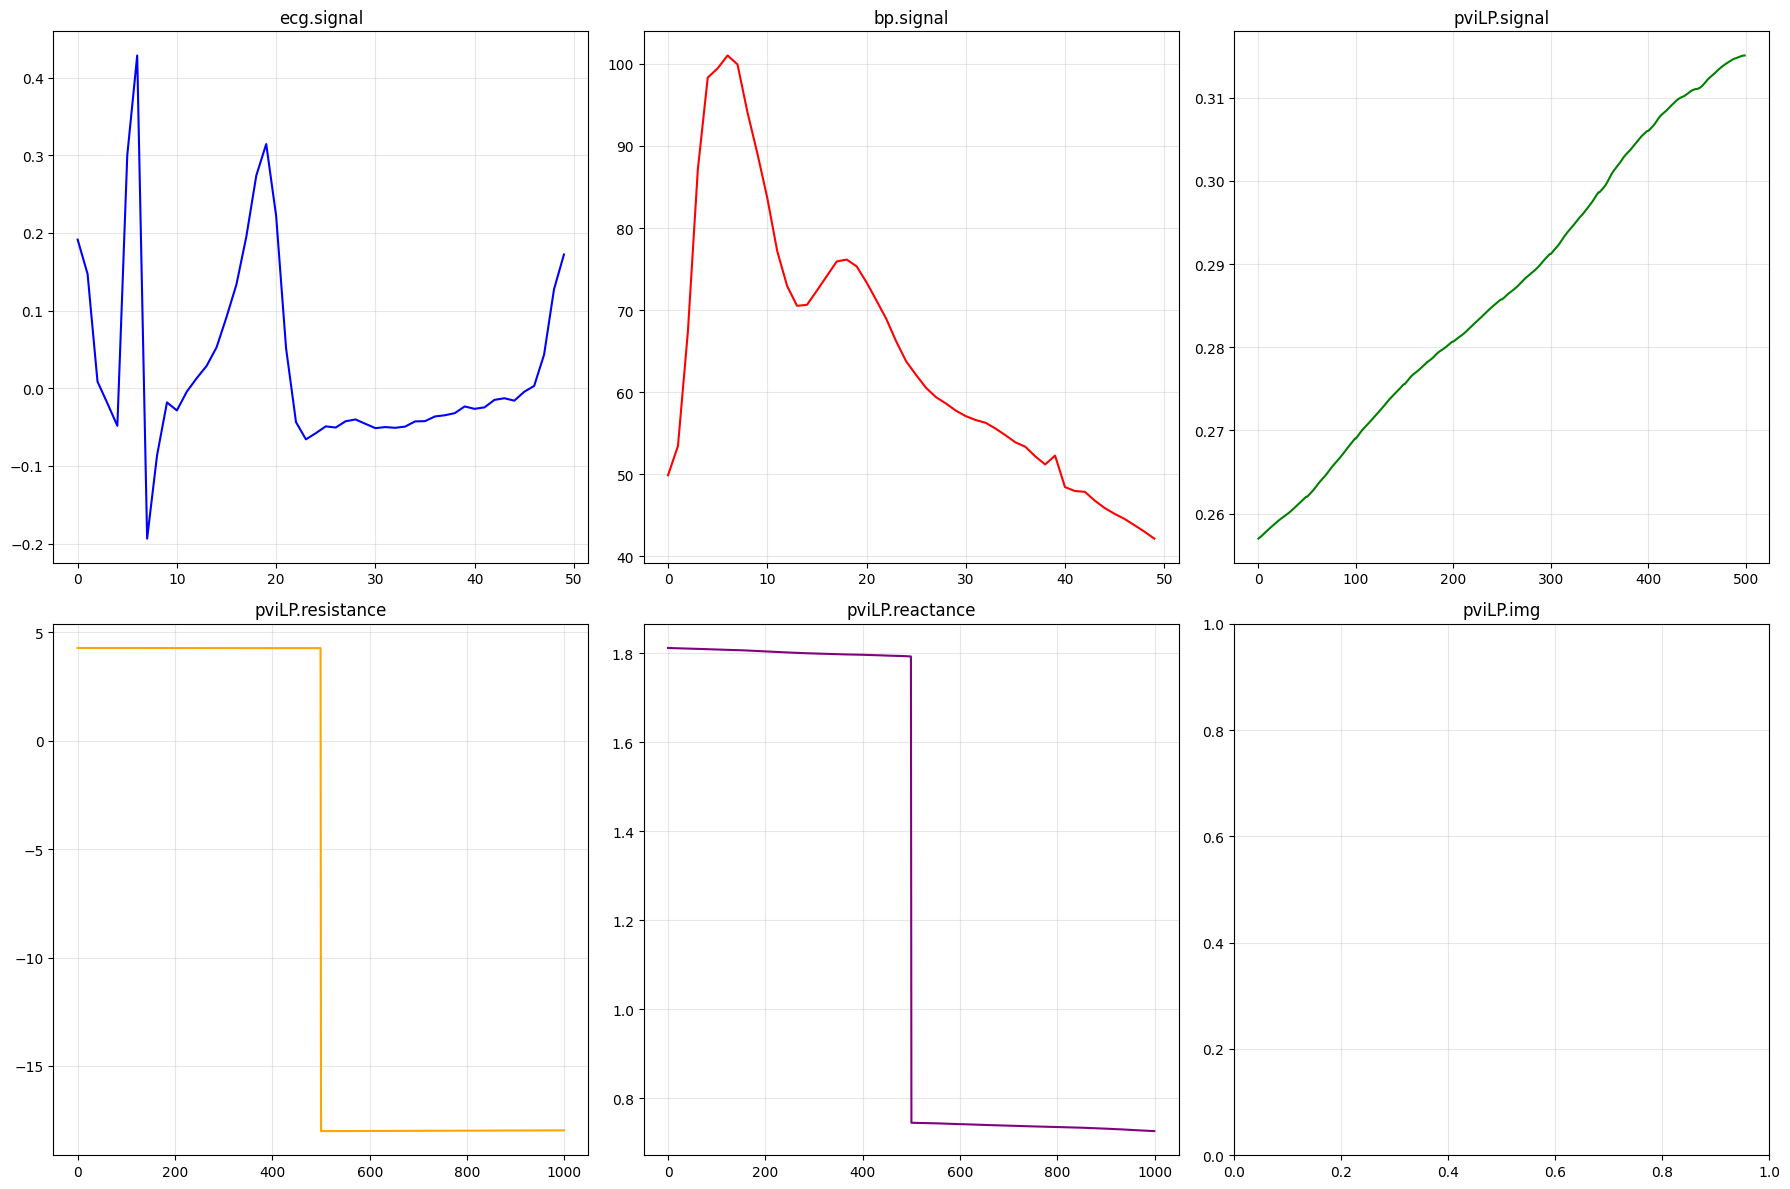

   ✅ Sample data visualization saved as 'sample_data_visualization.png'


In [16]:
def visualize_sample_data(dataset: PviDataset, sample_idx: int = 0):
    """Visualize data from a sample"""
    print(f"\n📊 Visualizing sample data (sample {sample_idx}):")
    
    if len(dataset) == 0:
        print("   ❌ Dataset is empty")
        return
    
    sample = dataset[sample_idx]
    
    try:
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()
        
        plot_idx = 0
        colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
        
        # Plot all signal data
        for key in sample.keys():
            if isinstance(sample[key], dict):
                for subkey in sample[key].keys():
                    if plot_idx < 6:  # Max 6 subplots
                        data = sample[key][subkey]
                        if isinstance(data, torch.Tensor):
                            if data.numel() > 1:  # Multi-dimensional tensor
                                if len(data.shape) == 1:  # 1D signal
                                    axes[plot_idx].plot(data.numpy(), 
                                                      color=colors[plot_idx % len(colors)])
                                elif len(data.shape) == 2:  # 2D data (e.g., image)
                                    if data.shape[0] < 100 and data.shape[1] < 100:  # Reasonable image size
                                        im = axes[plot_idx].imshow(data.numpy(), aspect='auto', cmap='viridis')
                                        plt.colorbar(im, ax=axes[plot_idx])
                                    else:  # Too large, plot as 1D
                                        axes[plot_idx].plot(data.flatten().numpy()[:1000], 
                                                          color=colors[plot_idx % len(colors)])
                                        axes[plot_idx].set_title(f'{key}.{subkey} (first 1000 points)')
                                        
                                axes[plot_idx].set_title(f'{key}.{subkey}')
                                axes[plot_idx].grid(True, alpha=0.3)
                                plot_idx += 1
                            else:  # Scalar
                                print(f"   📊 {key}.{subkey}: {data.item():.4f}")
        
        # Hide unused subplots
        for i in range(plot_idx, 6):
            axes[i].set_visible(False)
        
        plt.tight_layout()
        plt.savefig('sample_data_visualization.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"   ✅ Sample data visualization saved as 'sample_data_visualization.png'")
        
    except Exception as e:
        print(f"   ❌ Error creating sample visualization: {e}")

# Example usage - visualize sample data from first subject
if subjects:
    first_subject = subjects[10]
    print(f"\n📊 Visualizing sample data for: {first_subject}")
    data_manager = DataPathManager(
        subject=first_subject,
        session="baseline",
        root=data_root
    )
    
    if data_manager._h5_path.exists():
        dataset = PviDataset(str(data_manager._h5_path))
        visualize_sample_data(dataset)
    else:
        print(f"❌ File not found: {data_manager._h5_path}")
else:
    print("❌ No subjects available for sample visualization")
    
if subjects:
    first_subject = subjects[0]
    print(f"\n📊 Visualizing sample data for: {first_subject}")
    data_manager = DataPathManager(
        subject=first_subject,
        session="baseline",
        root=data_root
    )
    
    if data_manager._h5_path.exists():
        dataset = PviDataset(str(data_manager._h5_path))
        visualize_sample_data(dataset)
    else:
        print(f"❌ File not found: {data_manager._h5_path}")
else:
    print("❌ No subjects available for sample visualization")

In [8]:
def analyze_all_subjects():
    """Analyze all available subjects"""
    print("🚀 Complete Multi-Subject Dataset Analysis")
    print("=" * 60)
    
    # Setup data root
    data_root = os.getenv('BP_DATA_ROOT', '/home/lucas_takanori/phd/data')
    print(f"📁 Data root: {data_root}")
    
    # Get available subjects
    subjects = get_available_subjects(data_root)
    
    if not subjects:
        print("❌ No subjects found!")
        return
    
    print(f"\n✅ Found {len(subjects)} subjects: {subjects}")
    
    # Analyze each subject
    all_results = {}
    
    for i, subject in enumerate(subjects):
        print(f"\n{'='*60}")
        print(f"📋 Subject {i+1}/{len(subjects)}: {subject}")
        print(f"{'='*60}")
        
        try:
            # Create data manager
            data_manager = DataPathManager(
                subject=subject,
                session="baseline",
                root=data_root
            )
            
            # Check if file exists
            if not data_manager._h5_path.exists():
                print(f"⚠️  Data file not found: {data_manager._h5_path}")
                continue
            
            # Examine raw HDF5 structure
            h5_structure = examine_h5_file_structure(data_manager._h5_path)
            
            # Load dataset
            print(f"\n🔄 Loading PviDataset...")
            dataset = PviDataset(str(data_manager._h5_path))
            
            # Examine masks
            mask_info = examine_dataset_masks(dataset)
            
            # Examine sample structure
            sample_info = examine_sample_structure(dataset)
            
            # Store results
            all_results[subject] = {
                "file_path": str(data_manager._h5_path),
                "h5_structure": h5_structure,
                "mask_info": mask_info,
                "sample_info": sample_info,
                "num_samples": len(dataset)
            }
            
            # Visualize for first subject only
            if i == 0:
                visualize_masks(dataset)
                visualize_sample_data(dataset)
            
            print(f"✅ Successfully examined {subject}")
            
        except Exception as e:
            print(f"❌ Error examining {subject}: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    # Summary
    print(f"\n{'='*60}")
    print("📊 SUMMARY")
    print(f"{'='*60}")
    
    total_samples = sum(result["num_samples"] for result in all_results.values())
    subjects_with_masks = sum(1 for result in all_results.values() if result["mask_info"]["has_masks"])
    
    print(f"📈 Total subjects examined: {len(all_results)}")
    print(f"📈 Total samples across all subjects: {total_samples}")
    print(f"📈 Subjects with masks: {subjects_with_masks}/{len(all_results)}")
    
    if all_results:
        print(f"\n📋 Per-subject breakdown:")
        for subject, result in all_results.items():
            mask_status = "✅" if result["mask_info"]["has_masks"] else "❌"
            print(f"   {subject}: {result['num_samples']} samples, masks: {mask_status}")
    
    return all_results

# Run the complete analysis - uncomment the line below to execute
results = analyze_all_subjects()

# Or run it directly in the notebook:
print("🚀 To run complete analysis, execute:")
print("results = analyze_all_subjects()")

🚀 To run complete analysis, execute:
results = analyze_all_subjects()


In [9]:
def quick_test_single_subject(subject_name: str = None):
    """Quick test for a single subject"""
    data_root = os.getenv('BP_DATA_ROOT', '/home/lucas_takanori/phd/data')
    subjects = get_available_subjects(data_root)
    
    if not subjects:
        print("❌ No subjects found!")
        return
    
    # Use first subject if none specified
    test_subject = subject_name if subject_name else subjects[0]
    
    if test_subject not in subjects:
        print(f"❌ Subject {test_subject} not found in available subjects: {subjects}")
        return
    
    print(f"🧪 Quick test for subject: {test_subject}")
    
    # Load dataset
    data_manager = DataPathManager(
        subject=test_subject,
        session="baseline",
        root=data_root
    )
    
    dataset = PviDataset(str(data_manager._h5_path))
    
    print(f"📊 Dataset loaded: {len(dataset)} samples")
    
    # Examine first sample
    if len(dataset) > 0:
        sample = dataset[0]
        print(f"📋 Sample 0 structure:")
        for key, value in sample.items():
            if isinstance(value, dict):
                print(f"   {key}:")
                for subkey, subvalue in value.items():
                    if isinstance(subvalue, torch.Tensor):
                        print(f"      {subkey}: {subvalue.shape}")
                    else:
                        print(f"      {subkey}: {type(subvalue)}")
            else:
                if isinstance(value, torch.Tensor):
                    print(f"   {key}: {value.shape}")
                else:
                    print(f"   {key}: {type(value)}")
    
    return dataset

# Run quick test - execute this to test a single subject
if subjects:
    print("🧪 Running quick test on first subject...")
    dataset = quick_test_single_subject()
else:
    print("❌ No subjects available for quick test")

# You can also test a specific subject by name:
dataset = quick_test_single_subject("subject001")

🧪 Running quick test on first subject...
🔍 Scanning for subjects in: /home/lucas_takanori/phd/data
   Found: subject001_baseline_masked.h5
   Found: subject036_baseline_masked.h5
   Found: subject033_baseline_masked.h5
   Found: subject030_baseline_masked.h5
   Found: subject005_baseline_masked.h5
   Found: subject034_baseline_masked.h5
   Found: subject032_baseline_masked.h5
   Found: subject025_baseline_masked.h5
   Found: subject010_baseline_masked.h5
   Found: subject018_baseline_masked.h5
   Found: subject006_baseline_masked.h5
   Found: subject003_baseline_masked.h5
   Found: subject029_baseline_masked.h5
   Found: subject007_baseline_masked.h5
   Found: subject019_baseline_masked.h5
   Found: subject037_baseline_masked.h5
   Found: subject004_baseline_masked.h5
   Found: subject021_baseline_masked.h5
   Found: subject028_baseline_masked.h5
   Found: subject024_baseline_masked.h5
   Found: subject016_baseline_masked.h5
   Found: subject015_baseline_masked.h5
   Found: subject031_